# 22.3 · Metrics, confusion and thresholds

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain metrics, confusion and thresholds using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [09 · Feature Detection](../../09-feature-detection/README.md), [14 · Classical Segmentation](../../14-segmentation-classical/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Machine learning fits a rule from examples rather than specifying every visual condition manually. Features are measured inputs, labels are targets, and a held-out evaluation estimates behavior on new examples. Dataset design is part of the model, not administrative work after training.

## 2. Intuition

A confusion matrix counts predicted versus true classes. Precision asks how many predicted positives were correct; recall asks how many true positives were found. F1 balances the two, while ROC-AUC measures ranking across thresholds and needs both classes. Class imbalance and decision costs determine which metric is useful.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 22
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
Precision=TP/(TP+FP),\quad Recall=TP/(TP+FN)
$$

TP, FP and FN count true positives, false positives and missed positives. With TP=8, FP=2 and FN=4, precision=0.8 and recall=2/3. Zero denominators need an explicit reporting policy.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
tp, fp, fn = 8, 2, 4
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
print(precision, recall, f1)

0.8 0.6666666666666666 0.7272727272727272


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

A stratified split preserves approximate class proportions; a training-only scaler and LogisticRegression form the pipeline. The confusion matrix is measured on untouched test examples.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def machine_learning(lesson, seed, amount):
    x, y = load_digits(return_X_y=True)
    train_x, test_x, train_y, test_y = train_test_split(
        x, y, test_size=0.25, stratify=y, random_state=seed
    )
    model = make_pipeline(StandardScaler(), LogisticRegression(C=amount, max_iter=400))
    model.fit(train_x, train_y)
    prediction = model.predict(test_x)
    matrix = confusion_matrix(test_y, prediction)
    return Result(
        "22 · A leakage-safe digit-classification baseline",
        {"One held-out digit": test_x[0].reshape(8, 8), "Confusion matrix (row=true)": matrix},
        metrics={
            "held_out_accuracy": float(accuracy_score(test_y, prediction)),
            "train_samples": len(train_x),
            "test_samples": len(test_x),
            "dataset": "scikit-learn packaged digits; 8x8 images",
        },
        notes="Scaler fits only the training set. This seeded held-out result is specific to this dataset and split, not a general CV accuracy claim.",
    )

{
  "held_out_accuracy": 0.9777777777777777,
  "train_samples": 1347,
  "test_samples": 450,
  "dataset": "scikit-learn packaged digits; 8x8 images"
}
Scaler fits only the training set. This seeded held-out result is specific to this dataset and split, not a general CV accuracy claim.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import softmax

display(Code(inspect.getsource(softmax), language="python"))

def softmax(values, axis=-1):
    values = np.asarray(values, float)
    exp = np.exp(values - values.max(axis=axis, keepdims=True))
    return exp / exp.sum(axis=axis, keepdims=True)

## 8. Experiment

Compare raw-pixel and HOG features while keeping the split fixed. Tune settings on validation data before inspecting final test results.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "held_out_accuracy": 0.9777777777777777,
    "train_samples": 1347,
    "test_samples": 450,
    "dataset": "scikit-learn packaged digits; 8x8 images"
  },
  "second_seed": {
    "held_out_accuracy": 0.9733333333333334,
    "train_samples": 1347,
    "test_samples": 450,
    "dataset": "scikit-learn packaged digits; 8x8 images"
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

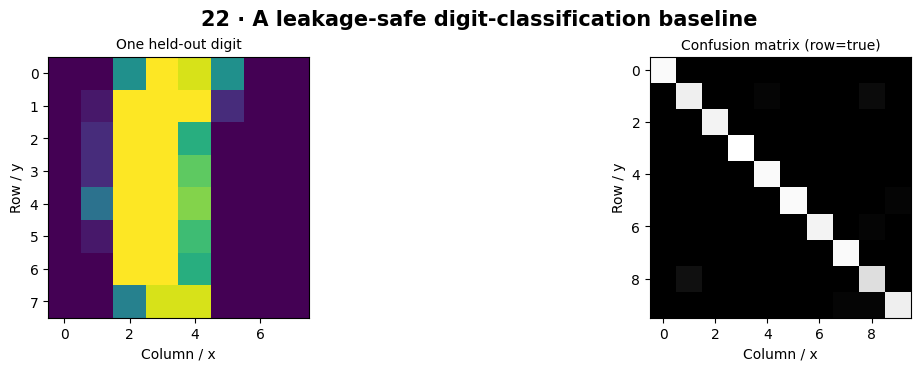

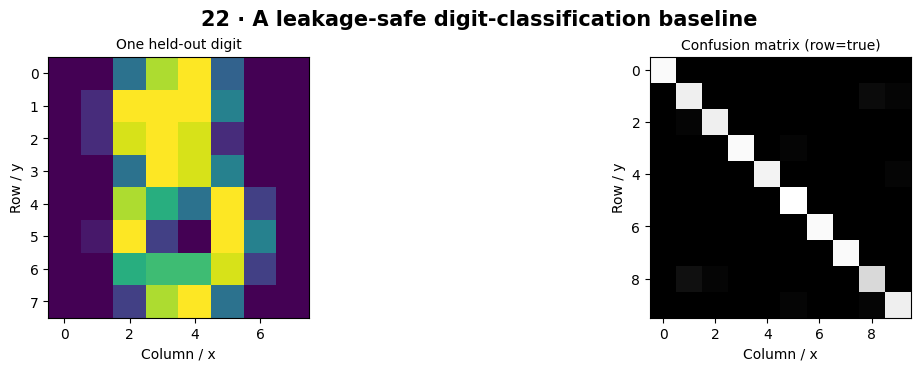

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Digit and Defect Classifier**. Evaluate a baseline with a genuinely held-out split. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Fitting a scaler or PCA before splitting leaks test distribution information. Accuracy can hide poor minority-class recall.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Compare raw-pixel and HOG features while keeping the split fixed. Tune settings on validation data before inspecting final test results.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a defect classifier with grouped splits, a validation-selected operating threshold and a test error analysis.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A confusion matrix counts predicted versus true classes. Precision asks how many predicted positives were correct; recall asks how many true positives were found. F1 balances the two, while ROC-AUC measures ranking across thresholds and needs both classes. Class imbalance and decision costs determine which metric is useful.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[23 · CNN Fundamentals](../../23-cnn-fundamentals/README.md)

[Primary reference](https://scikit-learn.org/stable/common_pitfalls.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)